<div class="rqT", title="📥 README first">

[**Click here: Local (cloning) *vs*. Google Colab**](./colab_vs_local.md)

if you choose a Google Colab cloud session, click on this icon (unless *you are already* in Google Colab):

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rpoteau/pyNanoMatBuilder/blob/main/pyNMB-examples.ipynb)

</div>

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



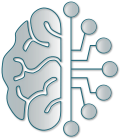

**Environment initialized:** Thursday 12 March 2026, 21:52:02 on localhost.localdomain

In [22]:
%load_ext autoreload
%autoreload 2

##################
# Initialization #
##################

import pyNanoMatBuilder as pyNMB
pyNMB.init()

<div class="introT" title="Structures available (sor far) in pyNMB">

<img src="./figs/pnmbAvailableStructures.png" style="margin-left:auto; margin-right:auto; display: block; width:1200px" id="img_pNMBAS" alt="Structures available in pyNMB"/>  

</div>

# Introduction 
</div>


<div class="intro">
    
**pyNanoMatBuilder** is a building tool for generating **3D structures of crystalline nanoparticles (NPs)** of various **shapes** and **sizes**, based on **user-defined compounds** either by name, e.g., "Fe bcc" (cf *data.py* and *cif_database* to see all available compounds and their acronyms) or from your CIF files directly (in the folder *userDefCifs*).

This notebook is a general demonstration of what is possible to do with pyNanoMatBuilder and shows all the shapes you can create, from Wulff constructions to magic number structures. 

Here's the content:
- **Creation of XYZ, CIF files and Jmol scripts** of the nanoparticles from all shape classes (cf. image above). Each class has its own parameters, so do not hesitate to read their documentation.

- **Geometry optimization** using ASE and pyNanoMatBuilder files.

- **More analysis tools** (symmetry, coordination numbers, etc.)

- **Bibliography**

*Note: If you directly want to create a database containing the NP structures and their scattering data, please refer to the `MakeNPsDatabase.ipynb` notebook.*

</div>


## Common Parameters

<div class="intro">
Key parameters available across all nanoparticle classes:

| Parameter | Type | Description |
|-----------|------|-------------|
| **`postAnalyzis`** | bool | Enable detailed analysis including unit cell properties, symmetry analysis, moment of inertia, surface/core informations, precise size informations |
| **`noOutput`** | bool | Suppress console output |
| **`skipSymmetryAnalyzis`** | bool | Skip symmetry calculations (useful for faster execution)  (if set to False, requires `postAnalyzis = True`) |
| **`jmolCrystalShape`** | bool | Generate Jmol visualization scripts (if set to True, requires `postAnalyzis = True`) |
| **`aseView`** | bool | Display structure using ASE viewer |
| **`thresholdCoreSurface`** | float | Threshold for core/surface atom classification |

</div>

# Crystal structure-based shapes

<div class="intro">
    
Either use the `Crystal` class of `pyNanoMatBuilder` or directly the [`ase.build.bulk` module](https://wiki.fysik.dtu.dk/ase/ase/build/build.html#common-bulk-crystals) of the `ase` library
</div>

In [6]:
from pyNanoMatBuilder import crystalNPs as cyNP
# If you want to read the class documentation:
cyNP.Crystal?

Init signature:
cyNP.Crystal(
    crystal: str = 'Au',
    scaleDmin2: float = None,
    setSymbols2: numpy.ndarray = None,
    userDefCif: str = None,
    shape: str = 'sphere',
    size: float = None,
    directionsPPD: numpy.ndarray = None,
    buildPPD: str = 'xyz',
    directionWire: float = None,
    directionCylinder: float = None,
    refPlaneWire: float = None,
    nRotWire: int = 6,
    hollow_sphere_diameter: float = None,
    surfacesWulff: numpy.ndarray = None,
    eSurfacesWulff: numpy.ndarray = None,
    sizesWulff: numpy.ndarray = None,
    symWulff: bool = True,
    jmolCrystalShape: bool = True,
    aseSymPrec: float = 0.0001,
    pbc: bool = False,
    threshold: float = 0.001,
    dbFolder: str = None,
    postAnalyzis: bool = True,
    aseView: bool = False,
    thresholdCoreSurface: float = 1.0,
    skipSymmetryAnalyzis: bool = False,
    noOutput: bool = False,
    calcPropOnly: bool = False,
)
Docstring:     
A class for generating XYZ and CIF files of crystalli

## Spheres

<div class="intro">
    
**The size parameter for the sphere is simply the diameter [d] in nm. Few examples are presented.**

</div>

### Au NPs

In [6]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make a sphere with a diameter of ~ 4 nm (4 nm will be the target size, the measured size will be slightly different due to compound cristalline organization)
sphere_diameter = [4] # diameter in nm
AuNP = cyNP.Crystal("Au fcc",size = sphere_diameter, shape = "sphere", thresholdCoreSurface = 1, skipSymmetryAnalyzis = False, noOutput = False)

# Save the files (XYZ, JMOL script, CIF) of the NP and also the core/surface model
pyNMBu.write("coords/SphericalAuNP.xyz", AuNP.NP) # XYZ file
pyNMBu.write("coords/SphericalAuNP_CoreSurface.xyz", AuNP.NPcs) # XYZ file of the core/surface model
AuNP.NP.center()
pyNMBu.write("coords/SphericalAuNP.cif", AuNP.NP) # CIF file
pyNMBu.write("coords/SphericalAuNP.script", AuNP.jMolCS) # JMOL script if postAnalyzis and jmolCrystalShape are True (they are by default)

CIF parameters for Au fcc found in cod9008463-Au_fcc.cif


Making a sphere with target radius = 2.000 nm


First making a 5x5x5 supercell
Making a 2x2x2 supercell of the supercell
       = 10x10x10 supercell
Center of Mass: ['19.37', '19.37', '19.37'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.0195625 -1.0195625 -1.0195625] Å
Total number of atoms = 4000
Duration : 00:00:00 003ms


Measured radius = 19.37 Å
Duration : 00:00:00 018ms
Total number of atoms = 1956


Bravais lattice: CUB(a=4.07825)
Chemical formula: Au4
Crystal family = cubic (lattice system = cubic)
Name = primitive cubic (Pearson symbol = cP)
Variant names = ['CUB']

From ase: space group number = 225      Hermann-Mauguin symbol for the space group = Fm-3m

a: 4.078 Å, b: 4.078 Å, c: 4.078 Å. (c/a = 1.000)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 67.830 Å3


...

Moments of inertia = 61223006.74 61223006.74 61223006.74 amu.Å2
Moments of inertia / M = 158.91 158.91 158.91 amu.Å2
Moments of inertia with mass=1/M = 158.91 158.91 158.91 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: Td
Rotational Symmetry Number = 12
Duration : 00:00:01 801ms


Found:
  - 132 vertices
  - 260 simplices
Duration : 00:00:00 003ms


448 atoms lie in the plane(s)
Duration : 00:00:00 005ms


diameters of the circumscribed sphere: 3.87 nm
diameters of the inscribed sphere: 3.87 nm


### Ru

In [7]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make a Ruthenium sphere of a diameter ~ 5 nm
RuNP = cyNP.Crystal("Ru hcp", shape= "sphere", size = [2]) # Other parameters set as default, see documentation

# Save the files( XYZ, JMOL script, CIF) and the core/surface model
pyNMBu.write("coords/SphericalRuNP.xyz", RuNP.NP) 
pyNMBu.write("coords/SphericalRuNP_cif.cif", RuNP.cif) 
pyNMBu.write("coords/SphericalRuNP_sc.cif", RuNP.sc) 
RuNP.NP.center()
pyNMBu.write("coords/SphericalRuNP.cif", RuNP.NP)
pyNMBu.write("coords/SphericalAuNP_sc.cif", RuNP.sc)
pyNMBu.write("coords/SphericalRuNP.script", RuNP.jMolCS) # JMOL script
pyNMBu.write("coords/SphericalRuNP_CoreSurface.xyz", RuNP.NPcs)  

CIF parameters for Ru hcp found in cod9008513-Ru_hcp.cif


Making a sphere with target radius = 1.000 nm


First making a 7x7x5 supercell
Making a 2x2x2 supercell of the supercell
       = 14x14x10 supercell
Center of Mass: ['9.46', '16.39', '21.41'] Å
Now translating the supercell to origin
Center of Mass after translation: [-6.75972497e-06  1.17081871e-05  1.04793084e-15] Å
Total number of atoms = 3920
Duration : 00:00:00 006ms


Measured radius = 9.63 Å
Duration : 00:00:00 061ms
Total number of atoms = 300


Bravais lattice: HEX(a=2.70389, c=4.28168)
Chemical formula: Ru2
Crystal family = hexagonal (lattice system = hexagonal)
Name = primitive hexagonal (Pearson symbol = hP)
Variant names = ['HEX']

From ase: space group number = 194      Hermann-Mauguin symbol for the space group = P6_3/mmc

a: 2.704 Å, b: 2.704 Å, c: 4.282 Å. (c/a = 1.584)
α: 90.000 °, β: 90.000 °, γ: 120.000 °

Volume: 27.110 Å3


...

Moments of inertia = 1182279.85 1192867.39 1192867.39 amu.Å2
Moments of inertia / M = 38.99 39.34 39.34 amu.Å2
Moments of inertia with mass=1/M = 38.99 39.34 39.34 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: Th
Rotational Symmetry Number = 6
Duration : 00:00:00 094ms


Found:
  - 72 vertices
  - 140 simplices
Duration : 00:00:00 002ms


144 atoms lie in the plane(s)
Duration : 00:00:00 002ms


diameters of the circumscribed sphere: 1.93 nm
diameters of the inscribed sphere: 1.93 nm


### TiO2

In [8]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make a TiO2 sphere of a diameter ~ 3 nm
TiO2rNP = cyNP.Crystal("TiO2 rutile", size= [3], thresholdCoreSurface = 1, skipSymmetryAnalyzis = False)

# Save the files( XYZ, JMOL script, CIF) and the core/surface model
pyNMBu.write("coords/SphericalTiO2rNP_cif.cif", TiO2rNP.cif)
pyNMBu.write("coords/SphericalTiO2ruNP_sc.cif", TiO2rNP.sc)
TiO2rNP.NP.center()
pyNMBu.write("coords/SphericalTiO2rNP.cif", TiO2rNP.NP)
pyNMBu.write("coords/SphericalTiO2rNP.xyz", TiO2rNP.NP)
pyNMBu.write("coords/SphericalTiO2rNP_CoreSurface.xyz", TiO2rNP.NPcs)
pyNMBu.write("coords/SphericalTiO2rNP.script", TiO2rNP.jMolCS)

CIF parameters for TiO2 rutile found in cod9015662-TiO2-rutile.cif


Making a sphere with target radius = 1.500 nm


First making a 4x4x7 supercell
Making a 2x2x2 supercell of the supercell
       = 8x8x14 supercell
Center of Mass: ['17.69', '17.69', '19.97'] Å
Now translating the supercell to origin
Center of Mass after translation: [-0.68830726 -0.68830726 -0.739675  ] Å
Total number of atoms = 5376
Duration : 00:00:00 004ms


Measured radius = 14.05 Å
Duration : 00:00:00 066ms
Total number of atoms = 1363


Bravais lattice: TET(a=4.5937, c=2.9587)
Chemical formula: O4Ti2
Crystal family = tetragonal (lattice system = tetragonal)
Name = primitive tetragonal (Pearson symbol = tP)
Variant names = ['TET']

From ase: space group number = 136      Hermann-Mauguin symbol for the space group = P4_2/mnm

a: 4.594 Å, b: 4.594 Å, c: 2.959 Å. (c/a = 0.644)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 62.435 Å3


...

Moments of inertia = 3253693.96 3292973.01 3302682.67 amu.Å2
Moments of inertia / M = 89.46 90.54 90.81 amu.Å2
Moments of inertia with mass=1/M = 89.53 90.31 90.57 Å2


Currently using the PointGroupAnalyzer class of pymatgen
The analyzis can take a while for large compounds

Point Group: D1d
Rotational Symmetry Number = 1
Duration : 00:00:01 742ms


Found:
  - 146 vertices
  - 288 simplices
Duration : 00:00:00 003ms


409 atoms lie in the plane(s)
Duration : 00:00:00 005ms


diameters of the circumscribed sphere: 2.81 nm
diameters of the inscribed sphere: 2.81 nm


### load an external cif file
**You can try it out with your own CIF files, just place them in the userDefCifs folder**

In [12]:
# imports
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# This time let's use CIF files from the user (put your CIF files in userDefCifs)
Fe2NNP = cyNP.Crystal(userDefCif="./userDefCifs/Fe2N-zeta-1668016.cif", shape = "sphere", size = [2], skipSymmetryAnalyzis = True)

# Save the files( XYZ, JMOL script, CIF) and the core/surface model
pyNMBu.write("coords/SphericalFe2N_NP_cif.cif", Fe2NNP.cif)
pyNMBu.write("coords/SphericalFe2N_NP_sc.cif", Fe2NNP.sc)
pyNMBu.write("coords/SphericalFe2N_NP.xyz", Fe2NNP.NP)
pyNMBu.write("coords/SphericalFe2N_NP_CoreSurface.xyz", Fe2NNP.NPcs)
pyNMBu.write("coords/SphericalFe2N_NP.script", Fe2NNP.jMolCS)
Fe2NNP.NP.center()
pyNMBu.write("coords/SphericalFe2N_NP.cif", Fe2NNP.NP)

CIF parameters for Au found in Fe2N-zeta-1668016.cif


Making a sphere with target radius = 1.000 nm


First making a 4x4x5 supercell
Making a 2x2x2 supercell of the supercell
       = 8x8x10 supercell
Center of Mass: ['21.40', '18.92', '21.14'] Å
Now translating the supercell to origin
Center of Mass after translation: [-0.690375   -0.40255359 -0.98297543] Å
Total number of atoms = 7680
Duration : 00:00:00 007ms


Measured radius = 9.40 Å
Duration : 00:00:00 077ms
Total number of atoms = 428


Bravais lattice: ORC(a=4.425, b=4.83, c=5.523)
Chemical formula: Fe8N4
Crystal family = orthorhombic (lattice system = orthorhombic)
Name = primitive orthorhombic (Pearson symbol = oP)
Variant names = ['ORC']

From ase: space group number = 29      Hermann-Mauguin symbol for the space group = Pca2_1

a: 5.523 Å, b: 4.830 Å, c: 4.425 Å. (c/a = 0.801)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 118.042 Å3


Crystal = Au sphere


Moments of inertia = 698733.24 705224.05 726742.34 amu.Å2
Moments of inertia / M = 39.27 39.63 40.84 amu.Å2
Moments of inertia with mass=1/M = 39.12 39.95 41.20 Å2


Found:
  - 82 vertices
  - 160 simplices
Duration : 00:00:00 002ms


188 atoms lie in the plane(s)
Duration : 00:00:00 006ms


diameters of the circumscribed sphere: 1.88 nm
diameters of the inscribed sphere: 1.88 nm


### Hollow sphere

**It is also possible to make an hollow sphere, the new parameter is the diameter of the hollow in nm.**

In [13]:
# Imports
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu

# Let's make a sphere with a diameter of ~ 4 nm and a hollow of ~ 3 nm
sphere_diameter = [4] 
hollow_diamter = [3]

AuNP = cyNP.Crystal("Au fcc",size = sphere_diameter, hollow_sphere_diameter = hollow_diamter, shape = "sphere", thresholdCoreSurface=1, skipSymmetryAnalyzis = True,noOutput = False)

# Save the files (XYZ, JMOL script, CIF)
# Also possible to have a Core/Surface model 
pyNMBu.write("coords/SphericalHollowAuNP.xyz", AuNP.NP)
pyNMBu.write("coords/SphericalHollowAuNP.script", AuNP.jMolCS)
pyNMBu.write("coords/SphericalHollowAuNP_CoreSurface.xyz", AuNP.NPcs)
AuNP.NP.center()
pyNMBu.write("coords/SphericalHollowAuNP.cif", AuNP.NP)

CIF parameters for Au fcc found in cod9008463-Au_fcc.cif


Making a sphere with target radius = 2.000 nm


First making a 5x5x5 supercell
Making a 2x2x2 supercell of the supercell
       = 10x10x10 supercell
Center of Mass: ['19.37', '19.37', '19.37'] Å
Now translating the supercell to origin
Center of Mass after translation: [-1.0195625 -1.0195625 -1.0195625] Å
Total number of atoms = 4000
Duration : 00:00:00 003ms


Measured radius = 19.37 Å
Duration : 00:00:00 025ms
Total number of atoms = 1136


Bravais lattice: CUB(a=4.07825)
Chemical formula: Au4
Crystal family = cubic (lattice system = cubic)
Name = primitive cubic (Pearson symbol = cP)
Variant names = ['CUB']

From ase: space group number = 225      Hermann-Mauguin symbol for the space group = Fm-3m

a: 4.078 Å, b: 4.078 Å, c: 4.078 Å. (c/a = 1.000)
α: 90.000 °, β: 90.000 °, γ: 90.000 °

Volume: 67.830 Å3


Crystal = Au fcc sphere


Moments of inertia = 46852954.62 46852954.62 46852954.62 amu.Å2
Moments of inertia / M = 209.39 209.39 209.39 amu.Å2
Moments of inertia with mass=1/M = 209.39 209.39 209.39 Å2


Found:
  - 132 vertices
  - 260 simplices
Duration : 00:00:00 003ms


448 atoms lie in the plane(s)
Duration : 00:00:00 004ms


diameters of the circumscribed sphere: 3.87 nm
diameters of the inscribed sphere: 3.87 nm


## Ellipsoids

### Au

**The size parameters of the ellipsoids are the three diameter [a, b, c] in nm.**

In [ ]:
# Imports
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu
import importlib
importlib.reload(pyNMBu)
importlib.reload(cyNP)

# size = [a,b,c] : a, b, c being the diameters in the 3 directions
AuNP = cyNP.Crystal("Au fcc", shape='ellipsoid', size= [3, 5, 6], thresholdCoreSurface=2, skipSymmetryAnalyzis=True)

pyNMBu.writexyz("coords/EllipsoidalAuNP.xyz", AuNP.NP)
with open("coords/EllipsoidalAuNP.script", 'w') as f: f.write(AuNP.jMolCS)

### NaCl

In [ ]:
# Imports
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu
import importlib
importlib.reload(pyNMBu)
importlib.reload(cyNP)

# size=[a,b,c] : a, b, c being the diameters in the 3 directions
NaClNP = cyNP.Crystal("NaCl",shape='ellipsoid',size= [2, 4, 8],thresholdCoreSurface=2,skipSymmetryAnalyzis=True)

pyNMBu.writexyz("coords/EllipsoidalNaClNP.xyz", NaClNP.NP)
with open("coords/EllipsoidalNaClNP.script", 'w') as f: f.write(NaClNP.jMolCS)

## Parallelepipeds
**The size parameters are [a, b, c] the lengths of the parallelepiped in nm. The parallelepiped can be constructed using:**
- **"xyz"**: Cartesian coordinates (orthogonal axes)
- **"abc"**: Crystallographic unit cell vectors (may have non-90° angles)

<div class="rq">

*Note: When using "abc" mode, the cell vectors follow the compound's unit cell geometry. For non-orthogonal cells, the final dimensions may not be accurately calculated - this is currently under development.*
</div>




### Au fcc

In [ ]:
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib
importlib.reload(pyNMBu)
importlib.reload(cyNP)

# Size = [a, b, c] the lengths in nm
AuNP = cyNP.Crystal("Au fcc",shape='parallelepiped',size = [2,3,6],buildPPD='xyz',thresholdCoreSurface=2)

# Save the XYZ/CIF files and JMOL script
write("coords/AuParallelepiped.xyz", AuNP.NP)
write("coords/AuParallelepiped_sc.cif", AuNP.sc)
pyNMBu.writexyz("coords/AuParallelepiped_sc.xyz", AuNP.sc)
pyNMBu.writexyz("coords/AuParallelepiped_CoreSurface.xyz", AuNP.NPcs)
with open("coords/AuParallelepiped.script", 'w') as f: f.write(AuNP.jMolCS)

AuNP.NP.center()
write("coords/AuParallelepiped.cif", AuNP.NP)

### hcp Ru
The "abc" case.

In [ ]:
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib
importlib.reload(pyNMBu)
importlib.reload(cyNP)

# Size = [a, b, c] the lengths in nm
RuNP = cyNP.Crystal("Ru hcp", shape = 'parallelepiped', size = [8, 12, 4], buildPPD = 'abc', thresholdCoreSurface = 2, skipSymmetryAnalyzis = True, noOutput = False)

# Save the XYZ/CIF files and JMOL script
pyNMBu.writexyz("coords/RuParallelepiped.xyz", RuNP.NP)
write("coords/RuParallelepiped_sc.cif", RuNP.sc)
pyNMBu.writexyz("coords/RuParallelepiped_CoreSurface.xyz", RuNP.NPcs)
with open("coords/RuParallelepiped.script", 'w') as f: f.write(RuNP.jMolCS)

RuNP.NP.center()
write("coords/RuParallelepiped.cif", RuNP.NP)


## Wulff construction

**Wulff Construction:** You can either specify custom surface planes and their energies to create specific shapes (data available from [The Materials Project](https://next-gen.materialsproject.org/materials/), for example), or use our pre-defined Wulff shapes (see table below).

*Note: The size parameter represents the length between truncated surface planes, not the maximum nanoparticle dimension.*

### List of the pre-defined Wulff shapes in the `data.WulffShapes.WSdf` pandas dataframe

In [ ]:
import pandas as pd
from pyNanoMatBuilder import data
from pyNanoMatBuilder.data import WulffShapes as WS
importlib.reload(data)
pd.set_option('display.max_colwidth', 250)
display(WS.WSdf)
pd.set_option('display.max_colwidth', 50) ## revert

### fcc Au

In [ ]:
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu
import importlib
importlib.reload(pyNMBu)
importlib.reload(cyNP)

# You can define yourself the surface planes and their energies
sfW = [[1,1,1],[0,0,1]]
eW = [-3.0,-4]

# Define the target size between the truncated surface planes (~ 4 nm)
szW=[8]

AuNP = cyNP.Crystal("Au fcc",shape='Wulff',surfacesWulff=sfW,eSurfacesWulff=eW,sizesWulff=szW,thresholdCoreSurface=0.5, skipSymmetryAnalyzis= True,postAnalyzis=True,jmolCrystalShape=True,aseView= False)

# Save the XYZ, CIF files and JMOL script
write("coords/AuWulff_sc.cif", AuNP.sc)
pyNMBu.writexyz("coords/AuWulff.xyz", AuNP.NP)
with open("coords/AuWulff.script", 'w') as f: f.write(AuNP.jMolCS)

AuNP.NP.center()
write("coords/AuWulff.cif", AuNP.NP)

### hcp Ru

In [ ]:
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu
import importlib
importlib.reload(pyNMBu)
importlib.reload(cyNP)

# Define the surface planes and their energies
#sfW = [[0,5,1]]
#eW = [-1.0]
sfW = [[0,0,1],[1,0,0]]
eW = [2.598,2.877]

# Define the target size between the truncated surface planes (~ 6 nm)
szW = [6]

RuNP = cyNP.Crystal("Ru hcp",shape='Wulff: hcpwire',surfacesWulff=sfW,eSurfacesWulff=eW,sizesWulff=szW,threshold=1e-3,thresholdCoreSurface=2,postAnalyzis= True,jmolCrystalShape=True,aseView= False)

# Save the XYZ/CIF files and JMOL script
write("coords/RuWulff_sc.cif", RuNP.sc)
pyNMBu.writexyz("coords/RuWulff.xyz", RuNP.NP)
write("coords/RuWulff.cif", RuNP.NP)

with open("coords/RuWulff.script", 'w') as f: f.write(RuNP.jMolCS)

RuNP.NP.center()
write("coords/RuWulff.cif", RuNP.NP)

### Pre-defined Wulff shapes
No need to give the planes and their energies this time.

**Cuboctahedron of gold**

In [ ]:
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib
importlib.reload(pyNMBu)
importlib.reload(cyNP)
importlib.reload(data)

# Define the target size between the truncated surface planes (~ 5 nm)
szW = [5]

# The surface planes and energies are automatically retreived via data.py
TestNP = cyNP.Crystal("Au fcc",shape='Wulff: cubo',sizesWulff=szW,threshold=0.1,thresholdCoreSurface=2,postAnalyzis=True,jmolCrystalShape=True,aseView= False,noOutput=False,skipSymmetryAnalyzis=True)

# Save the XYZ/CIF files and JMOL script
write("coords/TestWulff_sc.cif", TestNP.sc)
pyNMBu.writexyz("coords/TestWulff.xyz", TestNP.NP)
#pyNMBu.writexyz("coords/TestWulff_CoreSurface.xyz", TestNP.NPcs)
with open("coords/TestWulff.script", 'w') as f: f.write(TestNP.jMolCS)

TestNP.NP.center()
write("coords/OhFeBeta.cif", TestNP.NP)

**Octahedron of gold**

In [ ]:
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu
# from pyNanoMatBuilder import data
# import importlib
importlib.reload(pyNMBu)
importlib.reload(cyNP)
importlib.reload(data)

# Define the target size between the truncated surface planes (~ 4 nm)
szW = [4]

# The surface planes and energies are automatically retreived via data.py
TestNP = cyNP.Crystal("Au fcc",shape='Wulff : Oh',sizesWulff=szW,threshold=0.1,thresholdCoreSurface=2,postAnalyzis=True,jmolCrystalShape=True,aseView= False,noOutput=False,skipSymmetryAnalyzis=True)

# Save the XYZ/CIF files and JMOL script
write("coords/TestWulff_sc.cif", TestNP.sc)
pyNMBu.writexyz("coords/TestWulff.xyz", TestNP.NP)
#pyNMBu.writexyz("coords/TestWulff_CoreSurface.xyz", TestNP.NPcs)
with open("coords/TestWulff.script", 'w') as f: f.write(TestNP.jMolCS)

TestNP.NP.center()
write("coords/TestWulff.cif", TestNP.NP)

**Hcp wire of Cobalt**

In [ ]:
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu
# from pyNanoMatBuilder import data
# import importlib
importlib.reload(pyNMBu)
importlib.reload(cyNP)
importlib.reload(data)

# Define the target size between the truncated surface planes (~ 3 nm)
szW = [3]

# The surface planes and energies are automatically retreived via data.py
TestNP = cyNP.Crystal("Co hcp",shape='Wulff : hcpwire',sizesWulff=szW,threshold=0.0001,thresholdCoreSurface=2,postAnalyzis=True,jmolCrystalShape=True,aseView= False,noOutput=False,skipSymmetryAnalyzis=True)

# Save the XYZ/CIF files and JMOL script
write("coords/TestWulff_sc.cif", TestNP.sc)
pyNMBu.writexyz("coords/TestWulff.xyz", TestNP.NP)
#pyNMBu.writexyz("coords/TestWulff_CoreSurface.xyz", TestNP.NPcs)
with open("coords/TestWulff.script", 'w') as f: f.write(TestNP.jMolCS)

TestNP.NP.center()
write("coords/TestWulff.cif", TestNP.NP)

**Rhombicuboctahedron of Iron (bcc)**

In [ ]:
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib
importlib.reload(pyNMBu)
importlib.reload(cyNP)

# Define the target size between the truncated surface planes (~ 4 nm)
szW = [4]

# The surface planes and energies are automatically retreived via data.py
RuNP = cyNP.Crystal("Fe bcc",shape='Wulff : rhcubo',sizesWulff=szW,threshold=1e-3,thresholdCoreSurface=2,postAnalyzis= True,jmolCrystalShape=True,aseView= False)

# Save the XYZ/CIF files and JMOL script
write("coords/RuWulff_sc.cif", RuNP.sc)
pyNMBu.writexyz("coords/RuWulff.xyz", RuNP.NP)
write("coords/RuWulff.cif", RuNP.NP)

with open("coords/RuWulff.script", 'w') as f: f.write(RuNP.jMolCS)

RuNP.NP.center()
write("coords/RuWulff.cif", RuNP.NP)

## Wires

**Key Parameters:**
- **directionWire** `[h, k, l]`: Miller indices defining the wire axis (e.g., `[1, 0, 0]`)
- **nRotWire**: Number of sides in the wire's cross-section (e.g., `4` for square, `6` for hexagonal)
- **size** `[diameter, length]`: Wire dimensions in nm (e.g., `[2, 8]`)
- **refPlaneWire** `[h, k, l]`: Miller indices of the reference plane, rotated around the growth direction to form the cross-section
- **pbc**: Periodic boundary conditions (True/False)




### fcc crystal (Au)

In [ ]:
import importlib
importlib.reload(pyNMBu)
importlib.reload(cyNP)

# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction=[1,0,0]
dim = [2,6]
refPlane = [0,0,1]
nRot = 4 # square cross-section

AuWire = cyNP.Crystal("Au fcc",shape='wire',size=dim,directionWire=direction,nRotWire=nRot,refPlaneWire=refPlane,pbc=False,skipSymmetryAnalyzis=False,threshold=3)

# Save the XYZ/CIF files and JMOL script
pyNMBu.writexyz("coords/AuWire.xyz", AuWire.NP)
with open(f"coords/NaClWire.script", 'w') as f: f.write(AuWire.jMolCS)


### hcp crystal (Co)

In [ ]:
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu

importlib.reload(cyNP)
importlib.reload(pyNMBu)

# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction = [0,0,1] 
dim = [1,8] 
refPlane = [1,0,0] 
nRot = 6 # hexagonal cross section

CoWire = cyNP.Crystal("Co hcp",shape='wire',size=dim,directionWire=direction,nRotWire=nRot,refPlaneWire=refPlane,pbc=False,aseView= False,skipSymmetryAnalyzis=True,threshold=3) #planeRotation pour générer des plans symétriques autour de l’axe du wire

# Save the XYZ/CIF files and JMOL script
pyNMBu.writexyz("coords/CoWire.xyz", CoWire.NP)
with open("coords/CoWire.script", 'w') as f: f.write(CoWire.jMolCS)

CoWire.NP.center()
write("coords/CoWire.cif", CoWire.NP)
CoWire.NPcs.center()
write("coords/CoWire_CoreSurface.cif", CoWire.NPcs)

### hcp crystal (Ru)

#### [0,0,1] RuNW with pbc and refPlane = (1 0 0) = [2 1 0] direction

In [ ]:
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu
importlib.reload(cyNP)
importlib.reload(pyNMBu)

# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction = [0,0,1] 
dim = [2,5]
refPlane = [1,0,0] 
nRot = 6 # hexagonal cross section

RuWire = cyNP.Crystal("Ru hcp",shape='wire',size=dim,directionWire=direction,nRotWire=nRot,refPlaneWire=refPlane,pbc= True,aseView= False,skipSymmetryAnalyzis=True) #planeRotation pour générer des plans symétriques autour de l’axe du wire

# Save the XYZ/CIF files and JMOL script
pyNMBu.writexyz("coords/RuWire.xyz", RuWire.NP)
with open("coords/RuWire.script", 'w') as f: f.write(RuWire.jMolCS)

RuWire.NP.center()
write("coords/RuWire.cif", RuWire.NP)
RuWire.NPcs.center()
write("coords/RuWire_CoreSurface.cif", RuWire.NPcs)


#### [1,0,0] RuNW with pbc and refPlane = [0,0,1]


In [ ]:
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu
importlib.reload(pyNMBu)
importlib.reload(cyNP)

# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction = [1,0,0]
dim = [3,6] 
refPlane = [0,0,1]
nRot = 6 # hexagonal cross section

RuWire = cyNP.Crystal("Ru hcp",shape='wire',size=dim,directionWire=direction,nRotWire=nRot,refPlaneWire=refPlane,pbc=True,aseView= False,skipSymmetryAnalyzis=True)

# Save the XYZ/CIF files and JMOL script
pyNMBu.writexyz("coords/RuWire.xyz", RuWire.NP)
with open("coords/RuWire.script", 'w') as f: f.write(RuWire.jMolCS)

RuWire.NPcs.center()
write("coords/RuWire_CoreSurface.cif", RuWire.NPcs)
RuWire.NP.center()
write("coords/RuWire.cif", RuWire.NP)

#### Pre-defined Wulff [0,0,1] nanowire
*Reminder: you can also create the wires using Wulff constructions.*

In [ ]:
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu

importlib.reload(cyNP)
importlib.reload(pyNMBu)
importlib.reload(data)

# Size is the length between the truncated surface planes
RuWire = cyNP.Crystal("Ru hcp",shape='Wulff: hcpwire',sizesWulff=[2], threshold=1e-3,thresholdCoreSurface=2,postAnalyzis=True)

# Save the XYZ/CIF files and JMOL script
pyNMBu.writexyz("coords/RuWire.xyz", RuWire.NP)
with open("coords/RuWire.script", 'w') as f: f.write(RuWire.jMolCS)
RuWire.NPcs.center()
write("coords/RuWire_CoreSurface.cif", RuWire.NPcs)
RuWire.NP.center()
write("coords/RuWire.cif", RuWire.NP)

### fcc crystal (Au)

#### [1,1,1] AuNW with pbc and refPlane = [2,1,1], *i.e.* a wrong truncation plane

In [ ]:
# import importlib
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu
importlib.reload(pyNMBu)
importlib.reload(cyNP)

vID.centerTitle(f"Au nanowire with wrong truncation reference plane and pbc")

# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction = [1,1,1]
dim = [2,4]
refPlane = [2,1,1]
nRot = 8

AuWire = cyNP.Crystal("Au fcc",shape='wire',size=dim,directionWire=direction,nRotWire=nRot,refPlaneWire=refPlane,pbc=True)

# Save the XYZ and CIF files
pyNMBu.writexyz("coords/AuWire.xyz", AuWire.NP)
write("coords/AuWire.cif", AuWire.NP)
write("coords/AuWire_CoreSurface.cif", AuWire.NPcs)

#### [1,1,1] Au nanowire with good truncation reference plane. Play with pbc True or False...

In [ ]:
# import importlib
# from pyNanoMatBuilder import utils as pyNMBu
# from pyNanoMatBuilder import crystalNPs as cyNP
importlib.reload(cyNP)
importlib.reload(pyNMBu)

# Define the shape parameters of the wire: growth direction, dimensions = [diameter, length], 
# refPlane =   Miller indices of the reference plane, which is rotated around "directionWire"
# nRot =  Number of sides in the wire's cross-section
direction=[1,1,1]
dim = [2,6]
refPlane = [0,1,-1]
nRot = 4

AuWire = cyNP.Crystal("Au fcc",shape='wire',size=dim,directionWire=direction,nRotWire=nRot,refPlaneWire=refPlane,pbc=False,skipSymmetryAnalyzis=False,threshold=3)

# Save the XYZ/CIF files
write("coords/AuWire.xyz", AuWire.NP)
write("coords/AuWire.cif", AuWire.NP)
write("coords/AuWire_CoreSurface.cif", AuWire.NPcs)

print(AuWire.jMolCS)

### Cylinder

**Key Parameters:**
- **directionCylinder** `[h, k, l]`: Miller indices defining the wire axis (e.g., `[1, 0, 0]`)
- **size** `[diameter, length]`: Cylinder dimensions in nm (e.g., `[2, 8]`)
- **pbc**: Periodic boundary conditions (True/False)


**The cylinder is defined by its size = [diameter, length] and its growth direction [h, k, l]**

In [ ]:
# from pyNanoMatBuilder import crystalNPs as cyNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib

importlib.reload(pyNMBu)
importlib.reload(cyNP)

# Define the cylinder parameters
dim = [3, 12] # diameter and length in nm
direction = [1, 1, 1] # growth direction

AuCylinder = cyNP.Crystal("Au fcc",shape= 'cylinder',size=dim,directionCylinder=direction,pbc=False,aseView= False,skipSymmetryAnalyzis=True,noOutput=False)

# Save the XYZ/CIF files and JMOL script
pyNMBu.writexyz("coords/Aufcccylinder_new.xyz", AuCylinder.NP)
with open("coords/Aufcccylinder.script", 'w') as f: f.write(AuCylinder.jMolCS)

AuCylinder.NPcs.center()
write("coords/Aufcccylinder_CoreSurface.xyz", AuCylinder.NPcs)
AuCylinder.NP.center()
write("coords/Aufcccylinder.cif", AuCylinder.NP)

<div class="rqE">

pbc in a general orientation is not an easy problem...
</div>

## Misc

### Change the atoms and size of the reference unit cell

<div class="intro">

In this example, the ruthenium hcp unitcell - that contains 2 Ru atoms - is used as a basis to build an hcp alloy with alternating Au/Ru planes, with the nearest neighbour bond length defined as 2.6 Å
</div>

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import utils as pyNMBu
importlib.reload(cyNP)
importlib.reload(pyNMBu)
CuAuNP = cyNP.Crystal("Ru hcp",shape='Wulff: cube',sizesWulff=[2],threshold=1e-3,thresholdCoreSurface=2,scaleDmin2=2.6, setSymbols2=['Au','Cu'], postAnalyzis=True,jmolCrystalShape=True, noOutput=True,)
pyNMBu.writexyz("coords/CuAualloy.xyz", CuAuNP.NP)

## With the ase.cluster.cubic class

In [ ]:
import tk
import numpy as np
import ase
from ase.io import write
from ase.visualize import view

import pyNanoMatBuilder.utils as pyNMBu

import ase
from ase.cluster.cubic import FaceCenteredCubic

lc = 3.82
surfaces = [(0,0,1),(1, 1, 1)]
layers = [4,4]
atoms = FaceCenteredCubic('Ru', surfaces, layers, latticeconstant=lc)
view(atoms)

# Magic number clusters and nanoparticles

## Magic numbers

In [ ]:
from pyNanoMatBuilder import data
from pyNanoMatBuilder import utils as pyNMBu
import importlib
importlib.reload(pyNMBu)
import pandas as pd
import numpy as np

pyNMBd = data.pyNMBdata()
print("clusters variable in data.py = ",pyNMBd.clusters)

vID.centerTitle("Single cluster type")
nmax = 20
cluster = 'regIco'
sizes = np.array(range(1,nmax+1))
print(f"Magic numbers for {cluster} = ",pyNMBu.magicNumbers(cluster,sizes))

vID.centerTitle("Store all magic numbers in a dataframe")
nmax = 12
sizes = np.array(range(1,nmax+1))
mndf = pd.DataFrame()
for c in pyNMBd.clusters:
    mn = pyNMBu.magicNumbers(c,sizes)
    mndf[c] = mn
mndf.set_index(sizes,inplace=True)
display(mndf)

## Platonic solids

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Platonic_solid)

[Wolfram MathWorld](https://mathworld.wolfram.com/PlatonicSolid.html)
</div>

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP

**The platonic module is dedicated to magic number structures: regular icosahedrons, tetrahedrons, octahedrons, dodecahedrons, and cubes.**

This module follows the same logic as the crystal module, but uses different size parameters depending on the construction geometry. Consult the documentation for each class to understand the specific parameter definitions:

**Size Parameters by Shape**

| Parameter | Shapes | Description |
|-----------|--------|-------------|
| **nOrder** | Octahedron, Cube | Number of nested shells in a Russian-doll configuration (imbrication level) |
| **nShell** | Icosahedron, Dodecahedron | Number of concentric shells built outward from the center |
| **nLayer** | Tetrahedron | Number of atomic layers, equivalently the number of atoms along an edge |

The distinction reflects different construction principles: **nOrder** represents structures built as nested polyhedra (like Russian dolls), while **nShell** describes structures grown layer-by-layer from a central core. Both **nOrder** and **nShell** correspond to the number of atomic layers along an edge, but their conceptual frameworks differ based on the geometric construction.

*Note: Standard platonic structures are fully implemented with accurate structural information. Specialized variants (double icosahedrons and tetrahedral helices) are functional but provide approximate dimensional data—these features are under active development.*

### Regular icosahedra

In [ ]:
# If you need to look at the documentation
# pNP.regIco?

Regular icosahedron with 5 shell(s) and Rnn = 2.7


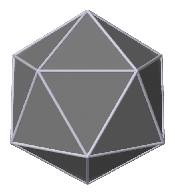

element =  Ag
number of vertices =  12
number of edges =  30
number of faces =  20
phi =  1.618033988749895
intershell factor = 1.05
nearest neighbour distance = 2.70 Å
intershell distance = 2.57 Å
edge length = 1.35 nm
radius after volume = 1.09 nm
radius of the circumscribed sphere = 1.28 nm
radius of the inscribed sphere = 1.02 nm
area = 15.8 nm2
volume = 5.4 nm3
number of atoms per shell =  [1, 12, 42, 92, 162, 252]
cumulative number of atoms per shell =  [1, 13, 55, 147, 309, 561]
total number of atoms =  561
Dual polyhedron: dodecahedron


Total number of atoms = 561
[1, 12, 42, 92, 162, 252]
Duration : 00:00:00 006ms


Moments of inertia = 3483379.35 3483379.35 3483379.35 amu.Å2
Moments of inertia / M = 57.56 57.56 57.56 amu.Å2
Moments of inertia with mass=1/M = 57.56 57.56 57.56 Å2


Found:
  - 12 vertices
  - 20 simplices
Duration : 00:00:00 001ms


252 atoms lie in the plane(s)
Duration : 00:00:00 001ms


In [25]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu

# Define the number of shells
nshells = 5
ico = pNP.regIco("Ag", 2.7 ,nshells,skipSymmetryAnalyzis=True,noOutput=False)
pyNMBu.write("coords/ico.xyz", ico.NP)
pyNMBu.write("coords/ico_CoreSurface.xyz", ico.NPcs)
pyNMBu.write("coords/ico.script", ico.jMolCS)

**The double icosahedron cluster: ongoing work**

A specific structure that can be found in the litterature, for example :
- https://link.springer.com/article/10.1007/s100530170149 (more theory)
- https://pubs.acs.org/doi/pdf/10.1021/acs.nanolett.3c04435 (more experimental)

*Note: the dimension informations are accurate for the initial icosahedron only.*

In [ ]:
# from pyNanoMatBuilder import platonicNPs as pNP
# from pyNanoMatBuilder import utils as pyNMBu
importlib.reload(pNP)
importlib.reload(pyNMBu)

# Define the number of shells
ico = pNP.regIco("Au", 2.7 , 8, double_ico = True, skipSymmetryAnalyzis=True,noOutput=False)
pyNMBu.writexyz("coords/ico.xyz", ico.NP)
pyNMBu.writexyz("coords/ico_CoreSurface.xyz", ico.NPcs) # algorithm struggling when concave ... still good to visualize the surface planes 
with open(f"coords/ico.script", 'w') as f: f.write(ico.jMolCS)

### Regular fcc tetrahedra

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Tetrahedron)
</div>

In [ ]:
# If you need to look at the documentation
# pNP.regfccTd?

In [ ]:
# from pyNanoMatBuilder import platonicNPs as pNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib
importlib.reload(pNP)
importlib.reload(pyNMBu)

# Let's make a regular gold tetrahedron of 16 layers 
Td = pNP.regfccTd("Au", 2.7, 5, noOutput=False)

# Save the XYZ/CIF files
pyNMBu.writexyz("coords/Td.xyz", Td.NP)
pyNMBu.writexyz("coords/Td_CoreSurface.xyz", Td.NPcs)
# with open(f"coords/Td.script", 'w') as f: f.write(Td.jMolCS)

**Helix of tetrahedrons: the Boerdijk-Coxeter helix**

Again, it is a specific structure, if you want to learn more about it, go to the */Docs/helices/* folder. 

The new parameter is simply :             
- n_tetrahedrons (int): The  number of tetrahedrons in the optionnal helix.
  
*Notes: the dimensions are for one tetrahedron only, and the total number of atoms given by JMOL is also false (because atoms from the reflected plane are counted twice).
Please refer to "Helix Informations". 
Developements ongoing.*

In [ ]:
# from pyNanoMatBuilder import platonicNPs as pNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib
importlib.reload(pNP)
importlib.reload(pyNMBu)

# Let's make an helix of 20 tetrahedron of 5 layers each
Td = pNP.regfccTd("Au", 2.7, nLayer = 5,  n_tetrahedrons = 20, postAnalyzis= True, skipSymmetryAnalyzis= True, noOutput=False) # postAnalyzis = True to have the Helix Informations

# Save the XYZ/CIF files
pyNMBu.writexyz("coords/Td.xyz", Td.NP)
pyNMBu.writexyz("coords/Td_CoreSurface.xyz", Td.NPcs)
# with open(f"coords/Td.script", 'w') as f: f.write(Td.jMolCS)

### Regular dodecahedra

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Dodecahedron)
</div>

In [ ]:
# If you need to look at the documentation
# pNP.regDD?

In [ ]:
# from pyNanoMatBuilder import platonicNPs as pNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib
importlib.reload(pNP)
importlib.reload(pyNMBu)

# Define the number of shells:
nshells = 5
rdd = pNP.regDD("Au",2.7, nShell = nshells,noOutput=False)

# Save the XYZ/CIF files and the JMOL script
pyNMBu.writexyz("coords/rdd.xyz", rdd.NP)
pyNMBu.writexyz("coords/rdd_CoreSurface.xyz", rdd.NPcs)
with open(f"coords/rdd.script", 'w') as f: f.write(rdd.jMolCS)

### Regular fcc octahedra

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Octahedron)
</div>

In [ ]:

# If you need to look at the documentation
# pNP.regfccOh?

In [ ]:
# from pyNanoMatBuilder import platonicNPs as pNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib

importlib.reload(pNP)
importlib.reload(pyNMBu)

# Define nOrder (the number of atomic layers along an edge)
fccOh = pNP.regfccOh("Au", 2.7, 5, noOutput=False, skipSymmetryAnalyzis=True)

# Save the XYZ/CIF files
pyNMBu.writexyz("coords/fccOh.xyz",fccOh.NP)
pyNMBu.writexyz("coords/fccOh_CoreSurface.xyz",fccOh.NPcs)

### Cubes

<div class="intro">

- [Wikipedia]()
- [Wolfram mathworld](https://mathworld.wolfram.com/Cube.html)
</div>

####  fcc cubes

In [ ]:
# If you need to look at the documentation
# pNP.cube?

In [ ]:
# from pyNanoMatBuilder import platonicNPs as pNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib
importlib.reload(pNP)
importlib.reload(pyNMBu)

t = pyNMBu.timer()
t.chrono_start()

# Define nOrder (the number of atomic layers along an edge)
fcc = pNP.cube('fcc','Au', Rnn= 2.7, nOrder = 2, noOutput=False, skipSymmetryAnalyzis = True, postAnalyzis= False) 

# Save the XYZ/CIF files
pyNMBu.writexyz("coords/fcccube_new.xyz", fcc.NP)
pyNMBu.writexyz("coords/fcccube_CoreSurface.xyz", fcc.NP)

print(t.chrono_stop(hdelay=True))
# with open(f"coords/fcccube.script", 'w') as f: f.write(fcccube.jMolCS)

#### bcc cubes

In [ ]:
# from pyNanoMatBuilder import platonicNPs as pNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib
importlib.reload(pNP)
importlib.reload(pyNMBu)

# Create a bcc cube of nOrder = 7
fcc = pNP.cube('bcc','Fe',Rnn= 2.47, nOrder = 7,noOutput=False,skipSymmetryAnalyzis = True)

# Save the XYZ file
pyNMBu.writexyz("coords/bcccube.xyz", fcc.NP)

### Hollow cubes

To create the hollow cube, first create a regular cube using the **cube** class, then create the hollow using the **hollow_shapes** with the following parameters:
- **full_cube:** instance of the cube class
- **nOrder_hollow:** nOrder of the hollow

*Note: nOrder of the hollow must be inferior to the nOrder of the cube.*


In [ ]:
# from pyNanoMatBuilder import platonicNPs as pNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib
importlib.reload(pNP)
importlib.reload(pyNMBu)

# Create the full cube
full_cube=pNP.cube('fcc','Au',Rnn=2.7, nOrder=9, noOutput=True, skipSymmetryAnalyzis = True) # nOrder of the full cube

# Create its hollow
hollow_cube= pNP.hollow_shapes(full_cube = full_cube, nOrder_hollow = 7, noOutput=False, skipSymmetryAnalyzis = True) # nOrder of the hollow

# Save the files
pyNMBu.writexyz("coords/fcccube.xyz", full_cube.NP)
pyNMBu.writexyz("coords/fcchollowcube.xyz", hollow_cube.NP)
#with open(f"coords/hollowcube.script", 'w') as f: f.write(hollow_cube.jMolCS)

## Archimedean solids

This class uses the `platonicNPs` module to generate the parent structures, then applies a truncation of ~33% (chosen to approximate more stable shapes).  
As a result, the size parameters follow the same definitions as in the Platonic classes.

**Size parameters (same convention as Platonic NPs)**

| Parameter | Shape(s) | Meaning |
|---|---|---|
| **nOrder** | Truncated octahedron, truncated cube | Number of nested shells in a Russian-doll configuration (imbrication level) |
| **nShell** | Cuboctahedron | Number of concentric shells built outward from the center |
| **nLayer** | Truncated tetrahedron | Number of atomic layers, equivalently the number of atoms along an edge |



In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import archimedeanNPs as aNP

### Cuboctahedron

<div class="intro">

- [Wikipedia](https://en.wikipedia.org/wiki/Cuboctahedron)
- [Wolfram mathworld](https://mathworld.wolfram.com/Cuboctahedron.html)
</div>


In [ ]:
# # If you want to read the documentation
# aNP.fccCubo?

In [ ]:
# from pyNanoMatBuilder import archimedeanNPs as aNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib

importlib.reload(aNP)
importlib.reload(pyNMBu)

# Let's make a cuboctahedron of 5 shells (number of atomic layers along an edge)
cubo = aNP.fccCubo("Au",2.7, 5, noOutput=False, postAnalyzis= False)

# Save the XYZ files and the JMOL script
pyNMBu.writexyz("coords/cubo.xyz", cubo.NP)
# pyNMBu.writexyz("coords/cubo_CoreSurface.xyz", cubo.NPcs)
# with open(f"coords/cubo.script", 'w') as f: f.write(cubo.jMolCS)

### Truncated fcc tetrahedron

<div class="intro">

- [Wikipedia](https://en.wikipedia.org/wiki/Truncated_tetrahedron)
- [Wolfram mathworld](https://mathworld.wolfram.com/TruncatedTetrahedron.html)
</div>

In [ ]:
# If you want to read the documenation
# aNP.fccTrTd?

In [ ]:
#from pyNanoMatBuilder import archimedeanNPs as aNP
#from pyNanoMatBuilder import utils as pyNMBu
#import importlib
importlib.reload(pyNMBu)
importlib.reload(aNP)

# Let's make a truncated tetrahedron from an tetrahedron of 16 shells
trTd = aNP.fccTrTd("Au", 2.7, 7, noOutput=False, postAnalyzis= True)

# Save the XYZ files and JMOL script
pyNMBu.writexyz("coords/Td-2truncate.xyz", trTd.NP0) # the initial tetrahedron
pyNMBu.writexyz("coords/trTd.xyz", trTd.NP) # the truncated one
# pyNMBu.writexyz("coords/trTd_CoreSurface.xyz", trTd.NPcs)
# with open(f"coords/trTd.script", 'w') as f: f.write(trTd.jMolCS)

### Truncated fcc octahedron

In [ ]:
# If you want to read the documentation
# aNP.fccTrOh?

In [ ]:
# from pyNanoMatBuilder import archimedeanNPs as aNP
# from pyNanoMatBuilder import platonicNPs as pNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib
importlib.reload(pNP)
importlib.reload(pyNMBu)
importlib.reload(aNP)

# Let's mahe a truncated octahedron from an octahedron of order = 12
trOh = aNP.fccTrOh("Au", 2.7, 12, noOutput=False,skipSymmetryAnalyzis=True)

# Save the XYZ files
pyNMBu.writexyz("coords/trOh_original.xyz", trOh.NP0) # the initial octahedron
pyNMBu.writexyz("coords/trOh_new.xyz", trOh.NP) # the truncated one


### Truncated fcc cube (in progress)

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Truncated_cube)

[Wolfram MathWorld](https://mathworld.wolfram.com/TruncatedCube.html)
</div>



In [ ]:
# if you want to read the documentation
# aNP.fccTrCube?

In [ ]:
from pyNanoMatBuilder import archimedeanNPs as aNP
from pyNanoMatBuilder import platonicNPs as pNP
from pyNanoMatBuilder import utils as pyNMBu
import importlib
importlib.reload(pNP)
importlib.reload(pyNMBu)
importlib.reload(aNP)

trCube = aNP.fccTrCube("Au", 2.7, 6, noOutput=False, calcPropOnly=False)
pyNMBu.writexyz("coords/Cube-2truncate.xyz", trCube.NP0)
pyNMBu.writexyz("coords/trCube.xyz", trCube.NP)
pyNMBu.writexyz("coords/trCube_CoreSurface.xyz", trCube.NPcs)
with open(f"coords/trCube.script", 'w') as f: f.write(trCube.jMolCS)

## Catalan solids

**Size parameter**

The **bcc rhombic dodecahedron** and **fcc dihedral rhombic dodecahedron** are constructed using a size parameter that defines the extent of the structure:

| Parameter | Description |
|-----------|-------------|
| **nShell** |  Number of concentric shells built outward from the center  |



In [ ]:
from pyNanoMatBuilder import catalanNPs as cNP


### Bcc rhombic dodecahedron (not working)


<div class="intro">

- [Wikipedia](https://en.wikipedia.org/wiki/Rhombic_dodecahedron)
- [Wolfram mathworld](https://mathworld.wolfram.com/RhombicDodecahedron.html)
</div>

In [ ]:
# If you want to read the documentation
# cNP.bccrDD?

In [ ]:
# from pyNanoMatBuilder import catalanNPs as cNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib

importlib.reload(cNP)
importlib.reload(pyNMBu)

# Let's make a rhombic dodecahedron of 5 shells
bccrdd = cNP.bccrDD("Fe", 2.47, 8, noOutput=False, skipSymmetryAnalyzis= True)

# Save the XYZ files and JMOL script
pyNMBu.writexyz("coords/bccrdd.xyz", bccrdd.NP)
pyNMBu.writexyz("coords/bccrdd_CoreSurface.xyz", bccrdd.NPcs)
with open(f"coords/bccrdd.script", 'w') as f: f.write(bccrdd.jMolCS)

### Fcc dihedral rhombic dodecahedron

In [ ]:
# If you want to read the documentation
# cNP.fccdrDD?

In [ ]:
# from pyNanoMatBuilder import catalanNPs as cNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib
importlib.reload(cNP)
importlib.reload(pyNMBu)

# Let's make a dihedral rhombic dodecahedron of 5 shells
fccdrdd = cNP.fccdrDD("Au", 2.7, 5, skipSymmetryAnalyzis = True, noOutput=False)

# Save the XYZ files and jmol script
pyNMBu.writexyz("coords/fccdrdd.xyz", fccdrdd.NP)
pyNMBu.writexyz("coords/fccdrdd_CoreSurface.xyz", fccdrdd.NPcs)
with open(f"coords/fccdrdd.script", 'w') as f: f.write(fccdrdd.jMolCS)

## Johnson solids

<div class="intro">

[Wikipedia](https://en.wikipedia.org/wiki/Johnson_solid)

[Wolfram MathWorld](https://mathworld.wolfram.com/JohnsonSolid.html)
</div>

This class defines **two shape families**:

**1. fcc trigonal bipyramid**

Size parameter:

| Parameter | Meaning |
|---|---|
| **nLayerTd** | Number of atomic layers in **one** tetrahedral pyramid. The full bipyramid has **2 × nLayerTd** layers (top + bottom). |

---

**2. pentagonal bipyramids, including elongated and truncated variants**

Size parameters:

| Parameter | Meaning |
|---|---|
| **sizeP** | Number of layers in the pentagonal cross-section (equivalently, number of bonds per pentagonal edge). |
| **sizeE** | Number of layers along the elongated height direction (number of bonds per elongated edge). |
| **Marks** | Truncation depth per pentagonal edge, expressed as number of atoms removed. The total truncation at a full vertex is **2 × Marks**. |



In [ ]:
from pyNanoMatBuilder import johnsonNPs as jNP

### Fcc trigonal bipyramid

In [ ]:
# If you want to read the documentation
# jNP.fcctbp?

In [ ]:
# from pyNanoMatBuilder import johnsonNPs as jNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib
importlib.reload(jNP)
importlib.reload(pyNMBu)

# Let's make a trigonal bipyramid from singular pyramids of 6 layers each  (= 12 layers in the bipyramid)
tbp = jNP.fcctbp("Au", 2.7, 17, noOutput=False, skipSymmetryAnalyzis = True)

# Save the XYZ files and jmol script
pyNMBu.writexyz("coords/Td-5tpb.xyz", tbp.NP0) # one pyramid
pyNMBu.writexyz("coords/tbp.xyz", tbp.NP) # the bipyramid
pyNMBu.writexyz("coords/tbp_CoreSurface.xyz", tbp.NPcs)
with open(f"coords/tbp.script", 'w') as f: f.write(tbp.jMolCS)

### Pentagonal bipyramids (decahedron) and elongated bipyramids

In [ ]:
# If you want to read the documentation
# jNP.epbpyM?

In [ ]:
# from pyNanoMatBuilder import johnsonNPs as jNP
# from pyNanoMatBuilder import utils as pyNMBu
# import importlib
importlib.reload(pyNMBu)
importlib.reload(jNP)


########################################################################################
# 1. Make a regular dodecahedron of 5 shells per edges
########################################################################################
sizeOfThePentagone = 5
sizeOfTheElongatedPart = 0
MarksTruncation = 0
ppy1 = jNP.epbpyM("Au", 2.7, sizeP = sizeOfThePentagone, sizeE = sizeOfTheElongatedPart, Marks = MarksTruncation, skipSymmetryAnalyzis= True,thresholdCoreSurface=1, noOutput=False)
pyNMBu.writexyz("coords/ppy1.xyz", ppy1.NP)
pyNMBu.writexyz("coords/ppy1_CoreSurface.xyz", ppy1.NPcs)
# with open(f"coords/ppy1.script", 'w') as f: f.write(ppy1.jMolCS)


########################################################################################
# 2. Make a dodecahedron of 5 shells with an elongation of 8 shells along its height
########################################################################################
sizeOfThePentagone = 5
sizeOfTheElongatedPart = 8
MarksTruncation = 0
ppy3 = jNP.epbpyM("Au",2.7,sizeP = sizeOfThePentagone,sizeE = sizeOfTheElongatedPart, Marks = MarksTruncation, skipSymmetryAnalyzis= True, thresholdCoreSurface=1,noOutput=False)
pyNMBu.writexyz("coords/ppy2.xyz", ppy3.NP)
pyNMBu.writexyz("coords/ppy2_CoreSurface.xyz", ppy3.NPcs)
# with open(f"coords/ppy3.script", 'w') as f: f.write(ppy3.jMolCS)


########################################################################################
# 3. Make a dodecahedron of 10 shells with a Marks truncation of 3 atoms per edge (= 6 atoms per vertices)
########################################################################################
sizeOfThePentagone = 10
sizeOfTheElongatedPart = 0
MarksTruncation = 3
ppy3 = jNP.epbpyM("Au",2.7, sizeP = sizeOfThePentagone, sizeE = sizeOfTheElongatedPart, Marks = MarksTruncation, skipSymmetryAnalyzis= True, noOutput=False)
pyNMBu.writexyz("coords/ppy3.xyz", ppy3.NP)
pyNMBu.writexyz("coords/ppy3_CoreSurface.xyz", ppy3.NPcs)
# with open(f"coords/ppy3.script", 'w') as f: f.write(ppy3.jMolCS)


########################################################################################
# 4. Combine 2. and 3. : Make dodecahedron of 10 shells with a elongation of 5 shells
# and a Marks truncation of 3 atoms per edge (= 6 atoms per vertices)
########################################################################################
sizeOfThePentagone = 10
sizeOfTheElongatedPart = 5
MarksTruncation = 3
ppy3 = jNP.epbpyM("Au",2.7, sizeP =sizeOfThePentagone, sizeE = sizeOfTheElongatedPart, Marks = MarksTruncation, skipSymmetryAnalyzis= True, noOutput=False)
pyNMBu.writexyz("coords/ppy4.xyz", ppy3.NP)
pyNMBu.writexyz("coords/ppy4_CoreSurface.xyz", ppy3.NPcs)
# with open(f"coords/ppy4.script", 'w') as f: f.write(ppy4.jMolCS)

## Other solids

For now, only the platelet exists. It is built by adding two truncated tetrahedrons to create a bipyramid, then potentially adding shells between the two pyramids.

Size parameter:

| Parameter | Meaning |
|---|---|
| **nLayerTd** | Number of layers (bonds per edge) of the two tetrahedrons used to create the platelet. This value will define the edge length of the final platelet; the number of layers of the platelet will be `nLayerTd + 1`. |
| **nLayer** | The number of layers kept for each tetrahedron (not counting the twin plane). This value will define the thickness of the platelet; the number of layers in the final platelet will be `nLayer * 2`. |


In [ ]:
from pyNanoMatBuilder import otherNPs as oNP

### Platelets

#### Triangular fcc platelets 

In [ ]:
# If you want to read the documentation
#  oNP.fcctpt?

In [ ]:
import sys
import pyNanoMatBuilder.utils as pyNMBu
from pyNanoMatBuilder import otherNPs as oNP
importlib.reload(pyNMBu)
importlib.reload(oNP)

# Let's make the double truncated tetrahedron with: 
lengthEdge = 15 # LENGTH OF THE PLATELET : 15 layers (bonds per edge) for each tetrahedrons, the final edge will have 16 layers (bonds per edge)
nshells = 3 # HEIGHT OF THE PLATELET : 3 shells kept for each tetrahedrons, the final number of shells will be 6 
tpt = oNP.fcctpt("Fe",2.47,lengthEdge,nshells,noOutput=False)

# Save the XYZ files and JMOL script
pyNMBu.writexyz("coords/tbp_4tpt.xyz", tpt.NP0)
pyNMBu.writexyz("coords/tpt.xyz", tpt.NP)
pyNMBu.writexyz("coords/tpt_CoreSurface.xyz", tpt.NPcs)
with open(f"coords/tpt.script", 'w') as f: f.write(tpt.jMolCS)


# Geometry optimization with ase

https://ase-lib.org/ase/calculators/emt.html

*Note: Supports the following standard EMT metals: Al, Cu, Ag, Au, Ni, Pd and Pt.*

In [ ]:
pyNMBu.optimizeEMT?

## Regular fcc octahedra

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP

# Create your NP structure
fccOh = pNP.regfccOh("Au", 2.7, 5)
aseOh = fccOh.NP
view(aseOh)

# Do the optimization
aseOhOpt = pyNMBu.optimizeEMT(aseOh,'./coords/fccOh')
view(aseOhOpt)

# Get some supplementary infos of the optimized structure
pyNMBu.moi(aseOhOpt)
pyNMBu.MolSym(aseOhOpt)

## Regular dodecahedra

In [ ]:
from pyNanoMatBuilder import platonicNPs as pNP

# Create your NP structure
rdd = pNP.regDD("Au",2.7,4)
aserdd = rdd.NP
view(aserdd)

# Do the optimization
aserddOpt = pyNMBu.optimizeEMT(aserdd,'./coords/rdd_opt.xyz')
view(aserddOpt)

# Get some supplementary infos of the optimized structure
pyNMBu.moi(aserddOpt)
pyNMBu.MolSym(aserddOpt)

## fcc Au ellipsoid

<div class="rq">

**warning!!!!!!!!!!!!!!!!!!!!!!!!!!!!**

With this fcc cif example (Au), center of mass is not at 0
whereas with hcp cif (Ru), translation operation puts center of mass at 0

is that a real problem?
</div>

In [ ]:
from pyNanoMatBuilder import crystalNPs as cNP

AuNP = cNP.Crystal("Au fcc",shape='ellipsoid',size=[1,1,2])
AuNP = AuNP.makeNP()
write("coords/AuNP_ellipsoid.xyz", AuNP)
AuNPopt = pyNMBu.optimizeEMT(AuNP,'./coords/AuNP_ellipsoid')

pyNMBu.moi(AuNPopt)
pyNMBu.MolSym(AuNPopt)

# Generation of simple structures for the documentation

## Platonic solids

In [ ]:
import importlib
importlib.reload(pyNMBu)
from pyNanoMatBuilder import data
importlib.reload(data)

vID.centerTitle("Platonic solids")

from pyNanoMatBuilder import platonicNPs as pNP
prefix="ico"
vID.centertxt(prefix)
ico = pNP.regIco("Pt",2.7,1, skipSymmetryAnalyzis = True, noOutput = True)
ase = ico.NP
del ase[0]
pyNMBu.saveCoords_DrawJmol(ase,prefix,"rotate x -110")

prefix="fccTd"
vID.centertxt(prefix)
fccTd = pNP.regfccTd("Pt",2.7,2, skipSymmetryAnalyzis = True, noOutput = True) ######################## spécifier que n=1 est impossible 
ase = fccTd.NP
pyNMBu.saveCoords_DrawJmol(ase,prefix,"moveto 1.0 { 176 811 559 126.41} 100.0 0.0 0.0 {0.0 0.0 0.0} 3.3534055 {0 0 0} 0 0 0 3.0 0.0 0.0;")

prefix="rDD"
vID.centertxt(prefix)
rDD = pNP.regDD("Pt",2.7,1, skipSymmetryAnalyzis = True, noOutput = True)
ase = rDD.NP
delete = [0,21,22,23,24,25,26,27,28,29,30,31,32]
del ase[delete]
pyNMBu.saveCoords_DrawJmol(ase,prefix,"rotate x 30")

prefix="fccOh"
vID.centertxt(prefix)
fccOh = pNP.regfccOh("Pt",2.7,1, skipSymmetryAnalyzis = True, noOutput = True)
ase = fccOh.NP
pyNMBu.saveCoords_DrawJmol(ase,prefix,"moveto 1.0 { 978 162 -135 101.36} 100.0 0.0 0.0 {0.0 0.0 0.0} 3.6091883 {0 0 0} 0 0 0 3.0 0.0 0.0;")

prefix="cube"
vID.centertxt(prefix)
bcccub = pNP.cube('bcc','Pt',2.7,1, skipSymmetryAnalyzis = True, noOutput = True)
ase = bcccub.NP
pyNMBu.saveCoords_DrawJmol(ase,prefix,"rotate y -20; rotate x 15")



## Archimedean

In [ ]:
###############################################################################
vID.centerTitle("Archimedean solids")

from pyNanoMatBuilder import archimedeanNPs as aNP
prefix="cubo"
vID.centertxt(prefix)
cubo = aNP.fccCubo("Pt",2.7,1)
ase = cubo.NP
del ase[0]
pyNMBu.saveCoords_DrawJmol(ase,prefix,"rotate y 45; rotate x 30")

prefix="trTd"
vID.centertxt(prefix)
trTd = aNP.fccTrTd("Pt",2.7,4)
ase = trTd.NP
delete = [12,13,14,15]
del ase[delete]
script = "rotate z 45; rotate x 60; draw id hex1 polygon [@2,@3,@9,@12,@6,@8]; draw id hex2 polygon [@1,@3,@9,@11,@5,@7];"\
         "draw id hex3 polygon [@4,@10,@6,@12,@11,@5]; draw id hex4 polygon [@2,@8,@10,@4,@7,@1]; color $hex* [x828282]"
pyNMBu.saveCoords_DrawJmol(ase,prefix,script)

from pyNanoMatBuilder import archimedeanNPs as aNP

prefix="trOh"
vID.centertxt(prefix)
trOh = aNP.fccTrOh("Pt",2.7,3)
ase = trOh.NP
pyNMBu.saveCoords_DrawJmol(ase,prefix,'select _Pt and connected(12,_Pt); delete selected; select all; select _Pt and connected(6,_Pt); delete selected; select *; rotate z 45; rotate x -15; draw POLYHEDRON @{{*}.find("*1****1||*1*****1","map")}; color DRAW [x828282]')



## Catalan solids

In [ ]:
###############################################################################
vID.centerTitle("Catalan solids")

from pyNanoMatBuilder import catalanNPs as cNP
prefix="bccrdd"
vID.centertxt(prefix)
bccrdd = cNP.bccrDD("Pt",2.7,1)
ase = bccrdd.NP
del ase[0]
pyNMBu.saveCoords_DrawJmol(ase,prefix,"connect 2.9 3.4 (_Pt)(_Pt) delete; rotate x -30")

from pyNanoMatBuilder import catalanNPs as cNP
prefix="fccdrdd"
vID.centertxt(prefix)
fccdrdd = cNP.fccdrDD("Pt",2.7,1)
ase = fccdrdd.NP
del ase[0]
script = "select _Pt and connected(5); connect (selected) delete; select all; "\
                                " rotate z 45; rotate x 45; "\
                                "draw id c711913 delete; draw id c713911 delete; draw id c911713 delete; draw id c913711 delete;"\
                                "draw id c8121014 delete; draw id c8141012 delete; draw id c1012814 delete;"
pyNMBu.saveCoords_DrawJmol(ase,prefix,script)

## Johnson solids

In [ ]:
###############################################################################
vID.centerTitle("Johnson solids")

from pyNanoMatBuilder import johnsonNPs as jNP
import importlib
importlib.reload(jNP)

prefix="tbp"
vID.centertxt(prefix)
tbp = jNP.fcctbp("Pt",2.7,10)
ase = tbp.NP
pyNMBu.writexyz("coords/tbp.xyz",tbp.NP)
pyNMBu.saveCoords_DrawJmol(ase,prefix,"rotate z 45; rotate x 35; rotate y -10; rotate x 10")

prefix="pbpy"
vID.centertxt(prefix)
pbpy = jNP.epbpyM("Pt",2.7,10)
ase = pbpy.NP
pyNMBu.writexyz("coords/pbpy.xyz",pbpy.NP )
pyNMBu.saveCoords_DrawJmol(ase,prefix,"rotate z 90; rotate x -85")

prefix="InoD"
vID.centertxt(prefix)
InoD = jNP.epbpyM("Pt",2.7,3,10)
ase = InoD.NP
pyNMBu.writexyz("coords/InoD.xyz", InoD.NP)
pyNMBu.saveCoords_DrawJmol(ase,prefix,"rotate z 90; rotate x -85")

prefix="MarksD"
vID.centertxt(prefix)
MarksD = jNP.epbpyM("Pt",2.7,3,0,1)
ase = MarksD.NP
script = 'rotate z 90;  select (_Pt and connected(8), _Pt and connected(12), _Pt and connected(9)); delete selected; select all;  connect 5.3 5.5 (_Pt) (_Pt);'\
         'draw id pol1 polygon [@4@1@2@6]; draw id pol2 polygon [@6@10@22@36];draw id pol3 polygon [@36@45@49@47]; draw id pol4 polygon [@47@48@44@34];'\
         'draw id pol5 polygon [@34@21@9@4];draw id pol6 polygon [@6@36@26]; draw id pol7 polygon [@36@47@26]; draw id pol8 polygon [@47@34@26];'\
         'draw id pol9 polygon [@34@4@26]; draw id pol10 polygon [@4@6@26]; color $pol* [x828282]'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script)

## Other solids

In [ ]:
###############################################################################
vID.centerTitle("Other solids")

from pyNanoMatBuilder import otherNPs as oNP
import importlib
importlib.reload(oNP)

from pyNanoMatBuilder import otherNPs as oNP
prefix="tpt"
vID.centertxt(prefix)
tpt = oNP.fcctpt("Pt",2.7,5,3,skipSymmetryAnalyzis=True)
ase = tpt.NP
script = 'select _Pt and connected(12,_Pt); delete selected; select all; rotate x -45; rotate y 35; rotate z 30; connect (_Pt)(_Pt) delete; connect @12 @15; connect @12 @14; connect @14 @15;  connect @1@3; connect @2 @3; connect @1 @2; connect @1 @12; connect @2 @14; connect @3 @15;'
script = script + 'select all; wireframe 0.3; cpk 0; select none; draw polygon [@1 @2 @3]; draw P1 polygon [@1 @2 @3]; draw P2 polygon [@12 @14 @15]; draw P3 polygon [@1 @12 @14 @2]; draw P4 polygon [@15 @3 @2 @14]; draw  P5 polygon [@15 @3 @1 @12]; color $P* [x828282]'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script)

## Crystal structure-based shapes

### Other than Wulff shapes

In [ ]:
import importlib
importlib.reload(pyNMBu)

###############################################################################
vID.centerTitle(f"Crystal structure-based shapes")
## simple drawing of spheres and ellipsoids with jmol

prefix="sphere"
vID.centertxt(prefix)
scriptJ = 'isosurface center {0 0 0} ellipsoid {10 0 0 1}; COLOR isosurface [x828282]; zoom 15; set showBoundBox TRUE'
pyNMBu.DrawJmol("at",prefix,scriptJ)

prefix="ellipsoid"
vID.centertxt(prefix)
scriptJ = 'isosurface center {0 0 0} ellipsoid {10 0 0 0.5}; COLOR isosurface [x828282]; zoom 15; set showBoundBox TRUE; rotate x 20'
pyNMBu.DrawJmol("at",prefix,scriptJ)

### Pre-defined Wulff shapes

#### Library

In [ ]:
import pandas as pd
from pyNanoMatBuilder import data
from pyNanoMatBuilder.data import WulffShapes as WS
importlib.reload(data)
pd.set_option('display.max_colwidth', 250)
display(WS.WSdf)
pd.set_option('display.max_colwidth', 50) ## revert

#### General Wulff structure

In [ ]:
from pyNanoMatBuilder import utils as pyNMBu
from pyNanoMatBuilder import crystalNPs as cyNP
from pyNanoMatBuilder import data
import importlib
importlib.reload(cyNP)
importlib.reload(pyNMBu)
importlib.reload(data)

###############################################################################
vID.centerTitle("Wulff shape")

prefix="WS"
sfW = [[0,0,1],[1,1,0]]
eW = [1.1,1.35]
szW = [2.2]
NP = cyNP.Crystal("Au fcc",shape='Wulff',surfacesWulff=sfW,eSurfacesWulff=eW,sizesWulff=szW,thresholdCoreSurface=2,postAnalyzis=True,jmolCrystalShape=True,noOutput=True)
# pyNMBu.writexyz("coords/Wulff-test-sc.xyz", NP.sc)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { 682 -730 -39 12.72} 100.0 0.0 0.0 {0.0 0.0 0.0} 17.613407 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script, boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

#### cub, trcub,cubo

In [ ]:
from pyNanoMatBuilder import utils as pyNMBu
from pyNanoMatBuilder import crystalNPs as cyNP
import importlib
importlib.reload(cyNP)
importlib.reload(pyNMBu)
importlib.reload(data)

###############################################################################
vID.centerTitle("pre-defined Wulff shapes")

prefix="cubeWS"
NP = cyNP.Crystal("Au fcc",shape='Wulff: cube',setSymbols2=['Pt','Pt','Pt','Pt'],sizesWulff=[2],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { 682 -730 -39 12.72} 100.0 0.0 0.0 {0.0 0.0 0.0} 17.613407 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script, boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

prefix="trcubeWS"
NP = cyNP.Crystal("Au fcc",shape='Wulff: trcube',setSymbols2=['Pt','Pt','Pt','Pt'],sizesWulff=[2],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { 682 -730 -39 12.72} 100.0 0.0 0.0 {0.0 0.0 0.0} 17.613407 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script, boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

prefix="cuboWS"
NP = cyNP.Crystal("Au fcc",shape='Wulff: cubo',setSymbols2=['Pt','Pt','Pt','Pt'],sizesWulff=[2],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { 682 -730 -39 12.72} 100.0 0.0 0.0 {0.0 0.0 0.0} 17.613407 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script, boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

#### Oh, trOh, dicoTd

In [ ]:
prefix="OhWS"
NP = cyNP.Crystal("Au fcc",shape='Wulff: Oh',setSymbols2=['Pt','Pt','Pt','Pt'],sizesWulff=[1],threshold=1e-3,thresholdCoreSurface=2,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { 639 -768 -48 14.05} 100.0 0.0 0.0 {0.0 0.0 0.0} 8.783736 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)
    
prefix="trOhWS"
NP = cyNP.Crystal("Au fcc",shape='Wulff: trOh',setSymbols2=['Pt','Pt','Pt','Pt'],sizesWulff=[1],threshold=1e-3,thresholdCoreSurface=2,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { 639 -768 -48 14.05} 100.0 0.0 0.0 {0.0 0.0 0.0} 8.783736 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

prefix="dicoTdWS"
NP = cyNP.Crystal("Au fcc",shape='Wulff: dicoTd',setSymbols2=['Pt','Pt','Pt','Pt'],sizesWulff=[5],threshold=1e-3,thresholdCoreSurface=2,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 {0 0 1 0} 90.0 0.0 0.0 {0.0 0.0 0.0} 30.557583 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

#### bccrDD, trbccrDD, ttrbccrDD

In [ ]:
from pyNanoMatBuilder import utils as pyNMBu
from pyNanoMatBuilder import crystalNPs as cyNP
import importlib
importlib.reload(cyNP)
importlib.reload(pyNMBu)
importlib.reload(data)

##############################################################################
prefix="bccrDDWS"
NP = cyNP.Crystal("Fe bcc",shape='Wulff: bccrDD',setSymbols2=['Pt','Pt'],sizesWulff=[1],threshold=1e-3,thresholdCoreSurface=2,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { -970 -210 -123 33.04} 100.0 0.0 0.0 {0.0 0.0 0.0} 7.4416 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

prefix="trbccrDDWS"
NP = cyNP.Crystal("Fe bcc",shape='Wulff: trbccrDD',setSymbols2=['Pt','Pt'],sizesWulff=[2],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + ';'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

prefix="ttrbccrDDWS"
NP = cyNP.Crystal("Fe bcc",shape='Wulff: ttrbccrDD',setSymbols2=['Pt','Pt'],sizesWulff=[1.0],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + '; moveto 1.0 { -60 633 772 173.14} 100.0 0.0 0.0 {0.0 0.0 0.0} 11.630102 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)


#### rhcubo, hcpsph1, hcpsph2

In [ ]:
from pyNanoMatBuilder import utils as pyNMBu
from pyNanoMatBuilder import crystalNPs as cyNP
import importlib
importlib.reload(cyNP)
importlib.reload(pyNMBu)
importlib.reload(data)

###############################################################################
prefix="rhcuboWS"
NP = cyNP.Crystal("Fe bcc",shape='Wulff: rhcubo',setSymbols2=['Pt','Pt'],sizesWulff=[1.8],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + ';moveto 1.0 { 245 964 101 46.71} 100.0 0.0 0.0 {0.0 0.0 0.0} 11.2082 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

prefix="hcpsph1WS"
NP = cyNP.Crystal("Ru hcp",shape='Wulff: hcpsph1',setSymbols2=['Pt','Pt'],sizesWulff=[1.8],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + ';moveto 1.0 { 1000 0 0 100.0} 100.0 0.0 0.0 {-6.67572E-6 1.1444092E-5 0.0} 13.109718 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

prefix="hcpsph2WS"
NP = cyNP.Crystal("Ru hcp",shape='Wulff: hcpsph2',setSymbols2=['Pt','Pt'],sizesWulff=[1.8],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=True,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + ';moveto 1.0 { 1000 0 0 100.0} 100.0 0.0 0.0 {-6.67572E-6 1.1444092E-5 0.0} 13.109718 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

#### hcpwire

In [ ]:
from pyNanoMatBuilder import utils as pyNMBu
from pyNanoMatBuilder import crystalNPs as cyNP
import importlib
importlib.reload(cyNP)
importlib.reload(pyNMBu)
importlib.reload(data)

###############################################################################
prefix="hcpwireWS"
NP = cyNP.Crystal("Ru hcp",shape='Wulff: hcpwire',setSymbols2=['Pt','Pt'],sizesWulff=[1.8],threshold=1e-3,thresholdCoreSurface=2,skipSymmetryAnalyzis=False,postAnalyzis=False,,jmolCrystalShape=True)
ase = NP.NP
script = NP.jMolCS + ';moveto 1.0 { 1000 0 0 100.0} 100.0 0.0 0.0 {-6.67572E-6 1.1444092E-5 0.0} 13.109718 {0 0 0} 0 0 0 3.0 0.0 0.0;'
pyNMBu.saveCoords_DrawJmol(ase,prefix,script,boundaries=True)
with open(f"figs/{prefix}.script", 'w') as f: f.write(NP.jMolCS)

## Convert the images to base64 code

In [ ]:
from PIL import Image
import glob, os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import base64
from io import BytesIO

folderFigs = './figs/'

listOfFigures = []
for fimg in glob.glob(folderFigs+"*-C.png"):
    prefix = fimg.split('/')[-1].split('.')[-2].split('-C')[-2]
    listOfFigures.append(prefix)
    vID.centertxt(f"{prefix}",size=14,weight='bold')
    with open(fimg, "rb") as img: 
        fbase64 = folderFigs + prefix + ".base64"
        print(f"{fimg} saved as {fbase64}")
        imgdata = img.read()
        # plt.figure(figsize=(2, 10))
        # plt.imshow(imgdata,interpolation='nearest')
        # plt.axis('off')
        # plt.show()
        encoded_image = base64.b64encode(imgdata)
        with open(fbase64, "wb") as base64file: 
            base64file.write(encoded_image)
        png = base64.b64decode(encoded_image)
        png = BytesIO(png)
        png = mpimg.imread(png, format='PNG')
        
        plt.figure(figsize=(2, 10))
        plt.imshow(png, interpolation='nearest')
        plt.axis('off')
        plt.show()

print(listOfFigures)

# Miscellaneous

## List all cif files available in the database

In [ ]:
from pyNanoMatBuilder import data
importlib.reload(pyNMBu)
importlib.reload(pyNMBu)

display(data.pyNMBcif.CIFdf)
pyNMBu.listCifsOfTheDatabase()

## Find all symmetry-equivalent planes

- [Cubic crystal system](https://en.wikipedia.org/wiki/Cubic_crystal_system)
- [Hexagonal crystal family](https://en.wikipedia.org/wiki/Hexagonal_crystal_family)

In [ ]:
from ase.spacegroup import Spacegroup
from pyNanoMatBuilder import utils as pyNMBu

# hcp
group=194
sg = Spacegroup(group)
vID.centerTitle(group)
print(sg)
plane = [1,0,0]
print(sg.equivalent_lattice_points(plane))

# fcc
group=225
sg = Spacegroup(group)
vID.centerTitle(group)
print(sg)
plane = [1,1,1]
print(sg.equivalent_lattice_points(plane))


## Save the coordination numbers in a dat file for jmol plots

In [ ]:
from pyNanoMatBuilder import crystalNPs as cyNP
importlib.reload(cyNP)
importlib.reload(pyNMBu)
RuNP = cyNP.Crystal("Ru hcp",shape='Wulff: hcpsph1',noOutput=True,sizesWulff=[2],threshold=1e-3,thresholdCoreSurface=2,postAnalyzis=True,jmolCrystalShape=True,)
write("coords/Ruhcp.xyz", RuNP.NP)
pyNMBu.saveCN4JMol(RuNP.NP,save2="coords/Ruhcp_CN.dat",Rmax=3.0)

# Bibliography

<div class="intro">

Mori, T.; Hegmann, T. (**2016**) Determining the Composition of Gold Nanoparticles: A Compilation of Shapes, Sizes, and Calculations Using Geometric Considerations. *J. Nanopart. Res.* **18**(10): 295, [link](https://doi.org/10.1007/s11051-016-3587-7)

Kaatz, F. H.; Bultheel, A. (**2019**) Magic Mathematical Relationships for Nanoclusters. *Nanoscale Res. Lett.* **14**(1): 150, [link](https://doi.org/10.1186/s11671-019-2939-5)

[4D Euclidean space](https://www.qfbox.info/4d/)

[https://rechneronline.de/pi/](https://rechneronline.de/pi/)
</div>

# To do (UPDATED 20240608). Deadline Christmas 2024
(NB. general target is 20x20 nm x 100 nm dimensions with 5 to 10 nm seeds)

- SASview > pdb is needed(Nicolas RR has written an xyz>pdb translator, see also `pyMatGen`)
- ~add the calculation of *G** => interplanar spacing and **calculation of the indices of the normal direction to any crystallographic plane defined by its Miller indices**  (<u>it is the same only in the cubic crystals case</u>)~
- ~decahedra, Ino and Marks decahedra => 5-fold symmetry nanowires~ (20240520)
- cylinders along any (hkl) direction > *converted as n-fold rotation faceting*
    - ~cubic systems~
    - ~hcp~
    - ~6-fold symmetry nanowires (i.e. hcp)~ (ok only if it lies along the c axis)
    - other- 3, 4, 5, 6, 8 bipyramids with elongation factor along *c* : as magic numbers twinned nanocrystals ~or as Wulff shapes~
    - nanowire in any [h,k,l] direction with periodic boundary conditions
- starting from a seed, add growth along any hkl direction
    - cubic systems
    - hcp
    - other
- add seeds of another metal, just as an inner ellipsoid
- implements an efficient algorithm to identify surface and core atoms
    - ~convex hull is ok for crystals that do not exhibit steps~
    - go beyond convex hull first strategy
    - calculate CN and CNeff, plot with jmol as a 3D map
- ~ase/pbc > generates a fifth column > delete (done by Nicolas)~

- include I(q)
- add a gui

# End

In [ ]:
vID.end(cwd0)

In [ ]:
from debyecalculator import DebyeCalculator
import torch
import numpy as np


def calcSofQ(xyzfile:str,qmin:float=1,qmax:float=25,qstep:float=0.01,biso:float=0.1,save=False):
    """
    xyz file: path to file produced by pyNMP- as this file contains 5 columns, it should be cleaned using the clean_xyz function
    qmin: min q value on which the Debye equation is computed
    qmax: max q value on which the Debye equation is computed
    qstep: step between successive q points
    biso: term for isotropic atomic displacement parameter
    """
    if torch.cuda.is_available():
        device='cuda'
    else:
        device='cpu'  
    calc = DebyeCalculator(qmin=qmin,qmax=qmax,qstep=qstep,device=device,biso=biso)
    Q, I =calc.iq(structure_source=xyzfile)
    # eventually add line to save data to file *.iq
    if save:
        filename=xyzfile.split('.')[:-1]+'_calc.iq'
        np.savetxt(filename,np.column_stack([Q,I]))
    return Q,I
    

def calcGofR(xyzfile:str,rmin:float=0,rmax:float=50,rstep:float=0.01,biso:float=0.1,qdamp:float=0,save=False):
    """
    xyz file: path to file produced by pyNMP- as this file contains 5 columns, it should be cleaned using the clean_xyz function
    qmin: min q value on which the Debye equation is computed
    qmax: max q value on which the Debye equation is computed
    qstep: step between successive q points
    biso: term for isotropic atomic displacement parameter
    qdamp: parameter to accune for PDF damping linked to truncation 
    """
    if torch.cuda.is_available():
        device='cuda'
    else:
        device='cpu'  
    calc = DebyeCalculator(rmin=rmin,rmax=rmax,rstep=rstep,device=device,biso=biso,qdamp=qdamp)
    r, G =calc.gr(structure_source=xyzfile)
    # eventually add line to save data to file *.gr
    if save:
        filename=xyzfile.split('.')[:-1]+'_calc.gr'
        np.savetxt(filename,np.column_stack([r,G]))
    return r,G 